# 03 · Feature engineering — variables, bloques y reserva de prueba
**Fase CRISP-DM:** preparación de los datos (2 de 2).

## Objetivo de este notebook

El preprocesamiento dejó una fila por zona H3 res 8 con la variable objetivo (`query_count`) y la población.
Aquí se agregan las variables que usará el modelado y se prepara la validación espacial:

1. **Variables territoriales:** población de las coronas vecinas y distancia al centro de referencia.
2. **Variables de contraste:** distancia al trazado GTFS y cobertura. Solo sirven para interpretar la brecha
   después; nunca entran al modelo.
3. **Grupos para las líneas base:** municipio y anillo de distancia.
4. **Validación espacial:** bloques H3 res 6 y una reserva de prueba del 20 % de los bloques, sorteada antes
   de cualquier modelo.

**Entradas:** `data/interim/celdas_objetivo.parquet`, `kontur_2023_h3r8.parquet`, `area_estudio.geojson`,
`queries_limpias.parquet`.

**Salidas:** `data/processed/tabla_modelado.parquet` y, en `resultados/03_feature_engineering/`,
`test_blocks.csv` (la reserva de prueba, versionada), tablas de resumen, figuras y `metricas.json`.

## 1. Configuración
Se ubica la raíz del proyecto, se cargan los parámetros de `config.py` y se borran las salidas anteriores de
esta fase para regenerarlas.

In [1]:
# Bootstrap: la raíz es la carpeta con pyproject.toml; se agrega a sys.path para importar config y trufi_ds
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [2]:
from trufi_ds.notebook_setup import *  # noqa: F403  config, pl, pd, np, plt, h3, guardar_*, cronometro
from trufi_ds import features as fe
from trufi_ds import preparation as prep
from trufi_ds import spatial

import json
import geopandas as gpd
from scipy.stats import spearmanr

FASE = "03_feature_engineering"
limpiar_salidas(FASE, [config.TABLA_MODELADO])
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
M = {}  # métricas de la fase → metricas.json al cierre
tiempo = cronometro()
AZUL, NARANJA, AQUA, AMARILLO, GRIS, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7", "#52514e"

## 2. Carga de los datos del preprocesamiento
**Tipo de datos:** tabla por zona (conteos y población), población Kontur de Bolivia, polígono del área y
consultas válidas.

Se leen los cuatro archivos que dejó `02_preprocesamiento`. La población Kontur se usa completa (todo Bolivia)
porque las coronas de las zonas del borde incluyen celdas fuera del área.

In [3]:
celdas = pl.read_parquet(config.CELDAS_OBJETIVO)
kontur = pl.read_parquet(config.KONTUR_H3R8)
limpias = pl.read_parquet(config.QUERIES_LIMPIAS, columns=["h3_origin", "origin_municipio"])
AREA = gpd.read_file(config.AREA_ESTUDIO).geometry.iloc[0]
print(f"Zonas: {celdas.height:,}  |  consultas válidas: {celdas['query_count'].sum():,}  |  Kontur: {kontur.height:,} celdas")
celdas.head(3)

Zonas: 1,628  |  consultas válidas: 1,924,578  |  Kontur: 145,929 celdas


h3_cell,query_count,user_count,population,query_count_antes_hueco,query_count_despues_hueco,query_rate_week,lat,lon
str,i64,i64,i64,i64,i64,f64,f64,f64
"""888b2c8001fffff""",35,22,253,34,1,0.4313,-17.429585,-66.27015
"""888b2c8003fffff""",3,3,10,3,0,0.037,-17.422968,-66.2754
"""888b2c8005fffff""",0,0,200,0,0,0.0,-17.428167,-66.261581


### 2.1 Verificación: los datos son los que dejó el preprocesamiento
Si el preprocesamiento cambió después de esta fase, las cifras no coinciden y hay que volver a ejecutarlo.

In [4]:
m_prep = json.loads((config.RESULTADOS / "02_preprocesamiento" / "metricas.json").read_text())
assert celdas.height == m_prep["celdas_objetivo"], "El número de zonas no coincide con el preprocesamiento"
assert celdas["query_count"].sum() == m_prep["consultas_validas"], "Las consultas no coinciden con el preprocesamiento"
print("Coinciden con resultados/02_preprocesamiento/metricas.json")

Coinciden con resultados/02_preprocesamiento/metricas.json


## 3. Centro de referencia
**Tipo de datos:** espaciales (un punto de referencia).

La distancia al centro resume el gradiente centro–periferia. Se usa la **Plaza 14 de Septiembre** y no el
centroide del área, por dos razones:

- En el EDA, la distancia a la Plaza se asocia más con las consultas que la distancia al centroide del área
  (Spearman impreso abajo, leído de `resultados/01_eda/metricas.json`). El centroide cae lejos del centro de
  actividad.
- La Plaza es exógena: no se calcula a partir de las consultas, así que la variable y los anillos que salen de
  ella no dependen de los datos que se van a predecir.

In [5]:
m_eda = json.loads((config.RESULTADOS / "01_eda" / "metricas.json").read_text())
print("Spearman de query_count con la distancia a la Plaza:", m_eda["spearman_query_count_dist_plaza_km"],
      "| al centroide:", m_eda["spearman_query_count_dist_centro_km"])
CENTRO = (config.CENTRO_REFERENCIA["lat"], config.CENTRO_REFERENCIA["lon"])
centroide = prep.area_center(AREA)
M["centroide_a_centro_km"] = round(float(prep.haversine_km(np.array([centroide[0]]), np.array([centroide[1]]), *CENTRO)[0]), 2)
print(f"Centro de referencia: {CENTRO}  |  centroide del área a {M['centroide_a_centro_km']} km")

Spearman de query_count con la distancia a la Plaza: -0.697 | al centroide: -0.476
Centro de referencia: (-17.393583, -66.157014)  |  centroide del área a 7.82 km


## 4. Variables territoriales
**Tipo de datos:** numéricos (población vecina y distancias) y espaciales (bloque H3).

Para cada zona:

- `pop_ring1`, `pop_ring2`: población Kontur de la primera y la segunda corona H3 (anillo exacto, sin la zona).
  Aproxima la demanda potencial del entorno sin usar consultas de otras zonas.
- `dist_centro_km`: distancia al centro de referencia.
- `block_id`: celda H3 res 6 que contiene la zona; es la unidad de validación.
- `edge_cell`: zona a 1 km o menos del borde del área (tiene menos vecinas).
- `lat`, `lon`, `x_utm`, `y_utm`: centroide en grados y en metros (UTM 19S).

In [6]:
tabla = prep.add_territorial_features(celdas, kontur, AREA, CENTRO)
tiempo("territoriales")
tabla.select("pop_ring1", "pop_ring2", "dist_centro_km", "edge_cell").describe()

⏱ territoriales: 0.6 s (acumulado 1 s)


statistic,pop_ring1,pop_ring2,dist_centro_km,edge_cell
str,f64,f64,f64,f64
"""count""",1628.0,1628.0,1628.0,1628.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",4479.502457,8805.224201,17.141387,0.095823
"""std""",6124.559672,11248.328675,9.070783,null
"""min""",0.0,2.0,0.511014,0.0
"""25%""",444.0,1089.0,10.208305,null
"""50%""",1709.0,3718.0,16.23689,null
"""75%""",6439.0,13210.0,22.047449,null
"""max""",28988.0,54207.0,41.771979,1.0


## 5. Variables de contraste GTFS
**Tipo de datos:** espaciales y de red (distancia al trazado de las líneas).

`dist_trazado_m` es la distancia del centroide de la zona al trazado GTFS más cercano (UTM 19S), y
`gtfs_covered` vale 1 si esa distancia es de `COBERTURA_M` o menos. **No son predictores:** el objetivo es
estimar la demanda esperada sin la red y usar la cobertura después, para interpretar dónde la demanda
observada queda por debajo de la esperada.

In [7]:
dist = spatial.distancia_trazado_m(tabla["lat"].to_numpy(), tabla["lon"].to_numpy(), config.GTFS_DIR,
                                   config.MUESTREO_TRAZADO_M)
tabla = tabla.with_columns(pl.Series("dist_trazado_m", dist.round(1)),
                           pl.Series("gtfs_covered", (dist <= config.COBERTURA_M).astype(np.int8)))
M["zonas_cubiertas"] = int(tabla["gtfs_covered"].sum())
tiempo("contraste")
print(f"Zonas a ≤ {config.COBERTURA_M} m del trazado: {M['zonas_cubiertas']:,} de {tabla.height:,}")

⏱ contraste: 2.3 s (acumulado 3 s)
Zonas a ≤ 500 m del trazado: 634 de 1,628


## 6. Municipio
**Tipo de datos:** categóricos (nombre del municipio).

Es el grupo de la línea base por municipio. Cada zona toma el municipio de origen más frecuente de sus
consultas, según la geocodificación de Trufi, con el texto reparado de *mojibake*. Las zonas sin consultas
toman el de la zona etiquetada más cercana. Es un atributo de ubicación, no un conteo.

In [8]:
tabla = prep.add_municipality(tabla, limpias)
M["municipios"] = tabla["municipality"].n_unique()
tiempo("municipio")
tabla["municipality"].value_counts(sort=True).head(8)

⏱ municipio: 3.4 s (acumulado 6 s)


municipality,count
str,u32
"""Cochabamba""",359
"""Sacaba""",324
"""Quillacollo""",152
"""Villa Santivañez""",125
"""Arbieto""",111
"""Villa José Quintín Mendoza""",99
"""Sipesipe""",97
"""Vinto""",95


## 7. Zonas del modelo
**Tipo de datos:** numéricos (población por zona).

Con menos de `POP_MIN` habitantes la tasa por habitante es inestable: una sola consulta equivale a más de 0,1
consultas por persona. Esas zonas quedan con `in_model = False`. También quedan fuera las zonas con consultas
pero sin población Kontur (*polos de actividad*, como terminales o mercados), porque no tienen exposición.

In [9]:
tabla = tabla.with_columns((pl.col("population") >= config.POP_MIN).alias("in_model"))
grupos = tabla.with_columns(
    pl.when(pl.col("in_model")).then(pl.lit(f"population ≥ {config.POP_MIN} (modelo)"))
    .when(pl.col("population") > 0).then(pl.lit(f"1 ≤ population < {config.POP_MIN}"))
    .otherwise(pl.lit("population = 0 (polos de actividad)")).alias("grupo"))
por_grupo = grupos.group_by("grupo").agg(pl.len().alias("zonas"), pl.col("query_count").sum().alias("consultas")).sort("grupo")
M.update({"zonas_modelo": int(tabla["in_model"].sum()),
          "consultas_modelo": int(tabla.filter(pl.col("in_model"))["query_count"].sum())})
guardar_tabla(por_grupo, "zonas_por_grupo", FASE)

grupo,zonas,consultas
str,u32,i64
"""1 ≤ population < 10""",204,140
"""population = 0 (polos de activ…",43,102
"""population ≥ 10 (modelo)""",1381,1924336


## 8. Anillos de distancia
**Tipo de datos:** categóricos ordenados (A1 = más cerca del centro … A4 = periferia).

Los anillos agrupan los bloques por cuartiles de su distancia media al centro. Sirven para dos cosas: son el
grupo de la línea base por anillo y estratifican el sorteo de la prueba, para que la prueba tenga bloques del
centro y de la periferia.

In [10]:
tabla, cortes = prep.add_distance_rings(tabla)
bloques = fe.bloques_del_modelo(tabla)
assert bloques["distance_ring"].n_unique() == config.N_ANILLOS
M["cortes_anillo_km"] = [round(float(c), 2) for c in cortes]
M["bloques_modelo"] = bloques.height
tiempo("anillos")
print(f"Cortes (km al centro): {M['cortes_anillo_km']}  |  bloques con zonas del modelo: {bloques.height}")

⏱ anillos: 0.1 s (acumulado 6 s)
Cortes (km al centro): [12.52, 18.65, 22.92]  |  bloques con zonas del modelo: 53


## 9. Correlación entre predictores
**Tipo de datos:** numéricos (asociación entre predictores).

Los tres predictores (`dist_centro_km`, `pop_ring1`, `pop_ring2`) y la exposición (`population`) no deberían
ser redundantes. Una correlación muy alta entre dos predictores haría inestables los coeficientes de los
modelos lineales. Se mide con Spearman sobre las zonas del modelo.

In [11]:
modelo = tabla.filter(pl.col("in_model"))
cols = ["population", *prep.PREDICTORS]
corr = pd.DataFrame([[round(float(spearmanr(modelo[a].to_numpy(), modelo[b].to_numpy())[0]), 3) for b in cols]
                     for a in cols], index=cols, columns=cols)
M["spearman_max_entre_predictores"] = float(corr.loc[prep.PREDICTORS, prep.PREDICTORS].where(
    ~np.eye(len(prep.PREDICTORS), dtype=bool)).abs().max().max())
guardar_tabla(pl.from_pandas(corr.reset_index(names="variable")), "correlacion_predictores", FASE)

variable,population,dist_centro_km,pop_ring1,pop_ring2
str,f64,f64,f64,f64
"""population""",1.0,-0.576,0.908,0.845
"""dist_centro_km""",-0.576,1.0,-0.646,-0.696
"""pop_ring1""",0.908,-0.646,1.0,0.954
"""pop_ring2""",0.845,-0.696,0.954,1.0


## 10. Reserva de prueba
**Tipo de datos:** espaciales (bloques H3 res 6).

Se sortea el `FRACCION_PRUEBA` de los bloques de cada anillo con la semilla de `config.py`. Los bloques de prueba
quedan fuera de todo el modelado (ajuste, validación cruzada y elección de técnica) y se usan **una sola vez**
en la evaluación. Se reserva por bloques, no por zonas sueltas, porque las zonas vecinas se parecen (autocorrelación
alta en el EDA, §11): una zona de prueba rodeada de zonas de entrenamiento daría un error optimista.
`test_blocks.csv` se versiona en Git antes de ajustar cualquier modelo.

In [12]:
prueba = fe.sortear_prueba(bloques, config.FRACCION_PRUEBA, config.SEMILLA)
guardar_tabla(prueba, "test_blocks", FASE)
tabla = tabla.with_columns(pl.col("block_id").is_in(prueba["block_id"].implode()).alias("in_test"))
modelo = tabla.filter(pl.col("in_model"))
particion = fe.resumen_por(modelo.with_columns(pl.when(pl.col("in_test")).then(pl.lit("prueba"))
                                               .otherwise(pl.lit("entrenamiento")).alias("conjunto")), "conjunto")
M.update({"bloques_prueba": prueba.height, "pct_consultas_prueba": float(particion.filter(pl.col("conjunto") == "prueba")["pct_consultas"].item())})
guardar_tabla(particion, "particion", FASE)

conjunto,bloques,zonas,consultas,poblacion,pct_zonas,pct_consultas,consultas_por_1000_hab
str,u32,u32,i64,i64,f64,f64,f64
"""entrenamiento""",41,1029,1738942,908744,74.51,90.37,1913.6
"""prueba""",12,352,185394,316935,25.49,9.63,585.0


In [13]:
# Partición por anillo: cuánto de cada anillo queda en prueba
guardar_tabla(fe.resumen_por(modelo.filter(pl.col("in_test")), "distance_ring"), "prueba_por_anillo", FASE)

distance_ring,bloques,zonas,consultas,poblacion,pct_zonas,pct_consultas,consultas_por_1000_hab
str,u32,u32,i64,i64,f64,f64,f64
"""A1""",3,133,127089,172615,37.78,68.55,736.3
"""A2""",3,119,58014,123611,33.81,31.29,469.3
"""A3""",3,30,140,7171,8.52,0.08,19.5
"""A4""",3,70,151,13538,19.89,0.08,11.2


⏱ prueba: 3.7 s (acumulado 10 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/03_feature_engineering/figuras/anillos_y_prueba.png')

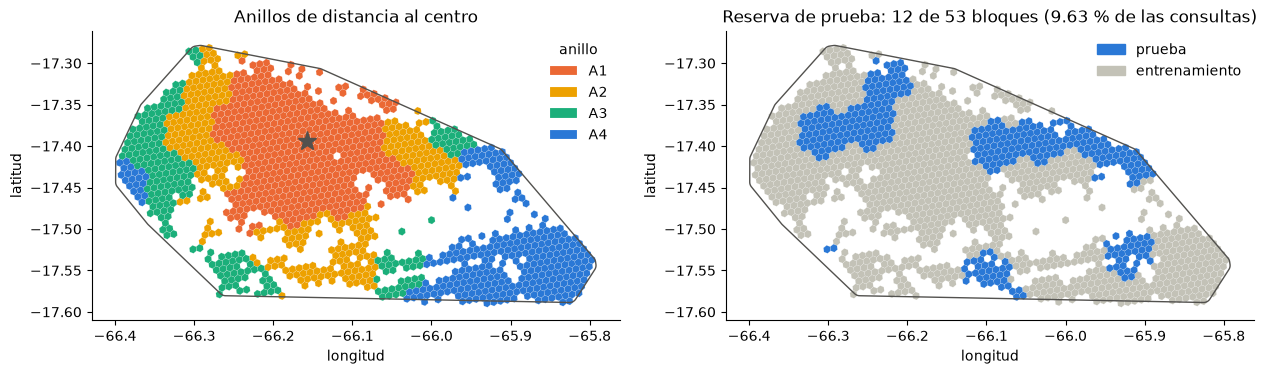

In [14]:
g = gpd.GeoDataFrame(modelo.select("h3_cell", "in_test", "distance_ring").to_pandas(),
                     geometry=prep.cell_polygons(modelo["h3_cell"].to_list()), crs="EPSG:4326")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6.5))
for anillo, color in zip(["A1", "A2", "A3", "A4"], [NARANJA, AMARILLO, AQUA, AZUL]):
    g[g["distance_ring"] == anillo].plot(ax=a1, color=color, edgecolor="white", linewidth=0.1, label=anillo)
a1.plot(CENTRO[1], CENTRO[0], marker="*", color=TINTA, ms=14, ls="")
a1.legend(frameon=False, title="anillo"); a1.set_title("Anillos de distancia al centro")
g[~g["in_test"]].plot(ax=a2, color=GRIS, edgecolor="white", linewidth=0.1)
g[g["in_test"]].plot(ax=a2, color=AZUL, edgecolor="white", linewidth=0.1)
a2.set_title(f"Reserva de prueba: {prueba.height} de {bloques.height} bloques ({M['pct_consultas_prueba']} % de las consultas)")
a2.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in (AZUL, GRIS)], labels=["prueba", "entrenamiento"], frameon=False)
for ax in (a1, a2):
    gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1); ax.set(xlabel="longitud", ylabel="latitud")
tiempo("prueba")
guardar_figura(fig, "anillos_y_prueba", FASE)

## 11. Verificaciones
Cada verificación tiene una intención; si alguna falla, el notebook se detiene.

### 11.1 Integridad de la tabla
La tabla conserva todas las consultas válidas, tiene una fila por zona y ningún valor nulo.

In [15]:
assert tabla["query_count"].sum() == m_prep["consultas_validas"], "Se perdieron consultas"
assert tabla["h3_cell"].is_unique().all(), "Hay zonas duplicadas"
assert tabla.null_count().sum_horizontal().item() == 0, "Hay valores nulos"
print(f"{tabla.height:,} zonas, {tabla['query_count'].sum():,} consultas, 0 nulos")

1,628 zonas, 1,924,578 consultas, 0 nulos


### 11.2 Rango de las variables
Poblaciones y distancias no negativas, y todas las zonas del modelo con al menos `POP_MIN` habitantes.
`pop_ring1` puede ser menor que `population`: la corona excluye la propia zona, así que una zona muy poblada
rodeada de zonas poco pobladas es un caso válido.

In [16]:
assert all(v >= 0 for v in tabla.select("population", "pop_ring1", "pop_ring2", "dist_centro_km", "dist_trazado_m").min().row(0))
assert (modelo["population"] >= config.POP_MIN).all()
assert (tabla["municipality"] != "desconocido").all(), "Hay zonas sin municipio"
n_corona_menor = int((modelo["pop_ring1"] < modelo["population"]).sum())
print(f"Rangos correctos. Zonas del modelo con pop_ring1 < population: {n_corona_menor}")

Rangos correctos. Zonas del modelo con pop_ring1 < population: 16


### 11.3 Partición sin solapamiento
Ningún bloque ni zona está a la vez en entrenamiento y prueba, y todos los anillos tienen bloques de prueba.
Las zonas de prueba del borde de un bloque sí pueden tocar zonas de entrenamiento: es inherente a partir por
bloques, y se cuantifica.

In [17]:
entreno, test = modelo.filter(~pl.col("in_test")), modelo.filter(pl.col("in_test"))
assert not set(entreno["block_id"]) & set(test["block_id"]), "Bloques compartidos"
assert not set(entreno["h3_cell"]) & set(test["h3_cell"]), "Zonas compartidas"
assert set(prueba["distance_ring"]) == set(bloques["distance_ring"]), "Algún anillo sin bloques de prueba"
celdas_entreno = set(entreno["h3_cell"])
M["zonas_prueba_con_vecina_entreno"] = sum(any(n in celdas_entreno for n in h3.grid_ring(c, 1)) for c in test["h3_cell"])
print(f"Sin solapamiento. Zonas de prueba que tocan entrenamiento: {M['zonas_prueba_con_vecina_entreno']} de {test.height}")

Sin solapamiento. Zonas de prueba que tocan entrenamiento: 125 de 352


### 11.4 Sin fuga de información
- El objetivo no está entre los predictores.
- Las variables GTFS no son predictores.
- Los predictores salen solo de Kontur y de la geometría. Ninguno usa consultas de otras zonas.
- La prueba se sorteó solo con bloques y anillos; los anillos dependen de un centro exógeno.

In [18]:
assert not set(prep.PREDICTORS) & set(prep.TARGETS), "El objetivo está entre los predictores"
assert not set(prep.PREDICTORS) & set(prep.CONTRAST), "Una variable GTFS está entre los predictores"
assert set(prep.PREDICTORS) == {"dist_centro_km", "pop_ring1", "pop_ring2"}, "Predictor no previsto"
assert set(prueba.columns) == {"block_id", "block_dist_km", "n_cells", "distance_ring"}, "El sorteo usó otra información"
print("Sin fuga:", {"predictores": prep.PREDICTORS, "contraste": prep.CONTRAST})

Sin fuga: {'predictores': ['dist_centro_km', 'pop_ring1', 'pop_ring2'], 'contraste': ['dist_trazado_m', 'gtfs_covered']}


## 12. Tabla de modelado
**Tipo de datos:** tabla final por zona.

Se guarda una sola vez y se relee para comprobar que el archivo es idéntico a la tabla en memoria.

| Columna | Rol | Descripción |
|---|---|---|
| `h3_cell` | identificador | zona H3 res 8 |
| `query_count` | objetivo | consultas válidas con origen en la zona |
| `user_count` | objetivo alternativo | usuarios distintos |
| `query_count_antes_hueco`, `query_count_despues_hueco`, `query_rate_week` | sensibilidad temporal | conteos por período y por semana observada |
| `population` | exposición | población Kontur 2023 (offset `log(population)`) |
| `pop_ring1`, `pop_ring2` | predictores | población de la 1.ª y 2.ª corona H3 |
| `dist_centro_km` | predictor | distancia a la Plaza 14 de Septiembre |
| `dist_trazado_m`, `gtfs_covered` | contraste | distancia al trazado GTFS y cobertura (≤ 500 m) |
| `municipality`, `distance_ring` | grupos | líneas base por municipio y por anillo |
| `block_id`, `in_test` | validación | bloque H3 res 6 y pertenencia a la prueba |
| `in_model`, `edge_cell` | filtros | población ≥ 10 y zona de borde |
| `lat`, `lon`, `x_utm`, `y_utm` | geometría | centroide en grados y en UTM 19S |

In [19]:
COLUMNAS = ["h3_cell", "query_count", "user_count", "query_count_antes_hueco", "query_count_despues_hueco",
            "query_rate_week", "population", "pop_ring1", "pop_ring2", "dist_centro_km", "dist_trazado_m",
            "gtfs_covered", "municipality", "distance_ring", "block_id", "in_test", "in_model", "edge_cell",
            "lat", "lon", "x_utm", "y_utm"]
final = tabla.select(COLUMNAS).sort("h3_cell")
final.write_parquet(config.TABLA_MODELADO)
assert pl.read_parquet(config.TABLA_MODELADO).equals(final), "El archivo no coincide con la tabla en memoria"
print(f"{config.TABLA_MODELADO.relative_to(config.PROJECT_ROOT)}: {final.shape}")

data/processed/tabla_modelado.parquet: (1628, 22)


In [20]:
M.update({"zonas": final.height, "columnas": final.width, "semilla": config.SEMILLA,
          "fraccion_prueba": config.FRACCION_PRUEBA, "pop_min": config.POP_MIN, "cobertura_m": config.COBERTURA_M})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.PROJECT_ROOT)}")

⏱ cierre: 2.0 s (acumulado 12 s)
17 métricas → resultados/03_feature_engineering/metricas.json
